# Advanced Course in Numerical Algorithms with Python/SciPy
Introduction to Python

## Content
1. [Modules](#modules)  
1. [Object oriented programming](#oop)
1. [Arrays](#arrays)
1. [Error handling](#error)
1. [Plotting](#plotting)

# 1. Modules <a id="modules"></a>

Python offers a very wide range of modules in the so-called standard library.

Examples are
* <code>math</code> - for complex mathematical calculations
* <code>complex</code> - for complex numbers
* <code>time</code> - for measuring performance 
* <code>copy</code> - for copying mutuable variables
* <code>sys</code> - Python system information

Modules can be import into your program via the command `import`:

In [1]:
# 1. possibility:
# We include the entire module:
import math
import random

# We can then access the individual functions of the module as follows.
print("Sinus of a random number", math.sin(random.random()))

Sinus of a random number 0.48334233355428285


In [2]:
# 2. possibility:
# You can internally give the loaded module a new name:
import math as mathematik
import random as rand
# We will use the numpy module very often. 
# It makes sense to abbreviate it:
import numpy as np

# It is used as follows:
print("Sinus of a random number:", mathematik.sin(rand.random()))
print("Sinus of pi:", mathematik.sin(np.pi))

Sinus of a random number: 0.15528507652765355
Sinus of pi: 1.2246467991473532e-16


In [3]:
# 3. possibility:
import math as mathematik, random as rand, numpy
# Works exactly as in the previous example.
# However, it is usually easier to read in the above form.

print("Sinus of a random number:", mathematik.sin(rand.random()))
print("Sinus of pi:", mathematik.sin(numpy.pi))

Sinus of a random number: 0.8006890833341874
Sinus of pi: 1.2246467991473532e-16


## Import individual functions from a module: `from ... import ...`

If you want to avoid always writing `math.` you can load single functions or all functions of a module at once:

In [4]:
import math
# Loading a single function
from math import sin
# Loading a function and assigning a new name:
from math import sin as sinus

x = math.pi/3
print("sin(x) =", sin(x))
print("sinus(x) =", sinus(x))

sin(x) = 0.8660254037844386
sinus(x) = 0.8660254037844386


In [5]:
# You can also load several functions and constants at once:
from math import sin, cos, sqrt, pi
from random import random

x = pi*pi*random()
print("sin(x)^2 + cos(x)^2 =", sin(x)**2 + cos(x)**2)

sin(x)^2 + cos(x)^2 = 1.0


Finally, all functions can be imported at once:

In [6]:
from math import *

print(log(exp(5)))

5.0


## What are modules?

A module is a collection of functions, definitions and classes that might be reused frequently and can be included in another Python program.

Modules are nothing else than Python files in special folders. A module with the name `my_module` is here in the form of a Python file with the name `my_module.py`.

### Example

We create a file named `my_first_module.py` in the current directory, i.e. the directory where this Jupyter notebook is located.

In [7]:
import my_first_module

After that, we can access the functions contained in it as we are used to:

In [8]:
import my_first_module
help(my_first_module)

Help on module my_first_module:

NAME
    my_first_module - dummy module to demonstrate how to write modules.

FUNCTIONS
    another_function_in_module(x)
    
    exp(x, /)
        Return e raised to the power of x.
    
    function_in_module()

FILE
    /home/andreas/Documents/Lund/Teaching/HT2023/AdvancedPython/PythonIntro/my_first_module.py




In [9]:
import my_first_module

my_first_module.function_in_module()
print(my_first_module.another_function_in_module(5))

Hello from the module!
It's pretty lonely over here!
742.065795512883


### Module paths

In our current working directory there is obviously no file named `math.py`. How does the Python interpreter find the file anyway?

Python examines a list of different folders in turn for the modules:

In [10]:
import sys

print("My search path for modules:")
for path in sys.path:
    print("'" + path + "'")

My search path for modules:
'/home/andreas/Documents/Lund/Teaching/HT2023/AdvancedPython/PythonIntro'
'/home/andreas/anaconda3/lib/python310.zip'
'/home/andreas/anaconda3/lib/python3.10'
'/home/andreas/anaconda3/lib/python3.10/lib-dynload'
''
'/home/andreas/anaconda3/lib/python3.10/site-packages'
'/home/andreas/anaconda3/lib/python3.10/site-packages/PyQt5_sip-12.11.0-py3.10-linux-x86_64.egg'
'/home/andreas/anaconda3/lib/python3.10/site-packages/mpmath-1.2.1-py3.10.egg'


The search starts in the current directory (the directory where the Jupyter Notebook is located) and continues until a corresponding module is found.

We can edit the `sys.path` list like any other list. For example, `sys.path += "module_folder"` can be used to add the subdirectory `module_folder` to the search path.

**Note:** A search for the file `math.py` fails, because the code for the math functions are built in as external library in the interpreter (programmed in C!). Reason: Performance!

### How are modules loaded?

The Python interpreter reads the file once when the `import my_module` command is called and then knows the contents of the module:

In [11]:
import my_module
# We include the file again:
import my_module

Test


* We see only one output. I.e. the code is evaluated once.
* Python knows the contents of the module after the first load and thus "skips" a new import statement.
* If we want to reload the package (for example inside the Python shell or in the Jupyter notebook), we can do this with `reload(module_name)` from the package `importlib`:

In [12]:
from importlib import reload

reload(my_module)
print()

Test



## Documentation for modules

Similar to functions, module descriptions are stored as comments. See `my_commented_module.py`

In [13]:
import my_commented_module
help(my_commented_module)

Help on module my_commented_module:

NAME
    my_commented_module - My commented module.

DESCRIPTION
    This module serves only the illustration of a complete documentation of a module. One should pay attention to the fact that just with modules always a description of the module and the individual functions is deposited.

FUNCTIONS
    solve_equation(a, b)
        This function solves the incredibly difficult problem
        a - b + x = 0.

FILE
    /home/andreas/Documents/Lund/Teaching/HT2023/AdvancedPython/PythonIntro/my_commented_module.py




### When should I create a module?

There are many cases when it makes sense to create a module:

  * The main program should be as short and easy to read as possible: Outsourcing of certain functions into several extra files.
  * The function is often needed in different parts of the program: In the appropriate code parts via `import modul` the module can be loaded simply.
  * The code should be outsourced and distributed (OpenSource, completely different application): Distributing the module is easier than distributing a complete program with the corresponding functions.
  
  * However, care should be taken to group the modules in a meaningful way:
  * Examples of sensible applications:
      *  Functions for input and output (for example input validation, file operations, special file formats like CSV or XML, ...).
      *  Commonly used calculation rules and operations: Linear algebra (matrices), numerical integration, optimization, zero search, ...
      * ...

## Summary:

* Loading/reloading modules
* Creating your own modules
* Python offers a lot of built-in modules: A look in the help is worthwhile (most of the time!).

## 2. Introduction to object oriented programming <a id="oop"></a>

Python is a so-called **object-oriented** programming language. We will explain this term in more detail below. We will first look at the well-known `type()` function:

In [14]:
print(type(1))
print(type(2))
print(type("a"))
print(type("b"))
print(type(set()))
print(type(lambda x: x*x))

<class 'int'>
<class 'int'>
<class 'str'>
<class 'str'>
<class 'set'>
<class 'function'>


We see here that, for example, the numbers `1` and `2` have a common type. This type is called a **class** in Python. The numbers `1,2` are so-called **objects** (or **instances**) of these classes.

We consider another example from the <code>numpy</code> library for representing general vectors in $\mathbb R^n$:


In [15]:
# numpy is a library for efficient creation
# and calculate with vectors and matrices:
import numpy as np

vector = np.array([1,2,3,4,5])
print(vector)
print(type(vector))

[1 2 3 4 5]
<class 'numpy.ndarray'>


Here we have included the data type `numpy.ndarray`. The `vector` is an **object** of the **numpy.ndarray** class.

## Classes and objects

The most important concepts for object-oriented programming are **classes and objects**:

Classes are "construction plans" for objects: A class describes data (or properties, attributes) and functions (methods) of the objects.

In particular, objects often have methods for read/write access to their data.

If no other access to the data of an object is possible than through its methods, one has realized an encapsulation of data.

We will consider a very simple and illustrative example:

<img src="cars.jpg" style="width: 30%; float:right" />

We consider the class of all cars. A set of properties can be defined for all cars. 

For example: 
 * number of doors 
 * number of seats 
 * power 
 * tank volume 
 * color 
 * ...

With the class "Car" we can thus describe all vehicles. I.e. we can represent all cars as **objects** of the **class** Car:

  *  `Car1` has 3 doors, 2 seats, 336 hp, 60 liters tank volume, silver, ...
  *  `Car2` has 5 doors, 5 seats, 136 hp, 50 liters tank volume, gray, ...
  
For given objects, i.e. concrete instances of the class Car, we can define methods that perform operations on the object. Some examples:

  * fill up
  * repaint
  * ...

### Examples of classes from mathematics
In mathematics, too, there are a number of objects that we can well define as classes:

* **Vectors / Matrices** in $\mathbb R^n$: $(x_1,\dots,x_n)^T \in \mathbb R^n$:
  * Attributes:
    * Coordinates $x_i$
    * Dimension $n$
    * Underlying space, e.g.: $\mathbb N$, $\mathbb C$ or $\mathbb R$
  * Methods:
    * Norm $\| x \|$
    * Addition $z = x + y$
    * Scalar multiplication: $\alpha x$
  * $\dots$

* **Polynomials:** $p(x) = \sum_{i=0}^n a_i x^i$.
  * Attribute: Coefficients $a_i$
  * Methods:
    * Evaluation of the polynomial at one point $x\in\mathbb R$: $p(x)$
    * Addition of two polynomials
    * Analytic integral, analytic derivative
  * $\dots$

* **Plots / Graphics**
  * Attributes
    * $x$ and $y$ values
    * Axis label
    * Color
  * Methods:
    * Output to the screen
    * Save to file
    * $\dots$

## Creating classes and objects

In Python, classes are defined using the `class` keyword:

In [16]:
class Car:
    """
    Class for modeling automobiles.
    """
    pass

In [17]:
car1 = Car()
car2 = Car()
print(type(car1))
print(type(car2))
print(car1 is car2)
print(isinstance(car1, Car))

<class '__main__.Car'>
<class '__main__.Car'>
False
True


### Attributes of a class

Of course, an empty class is not of much use. One of the most important features is the storage of attributes within the class:

In [18]:
c1 = Car()
c1.color = "red"
c1.age = 15

c2 = Car()
c2.color = "green"
c2.age = 2

print(c1.color)

red


The attributes are stored within the class as `dict` object. They can be accessed directly with `__dict__`:

In [19]:
c1 = Car()
c1.color = "red"
c1.age = 15

print(c1.__dict__)

{'color': 'red', 'age': 15}


So we could have worked with dictionaries from the beginning?!

So what are the advantages of a class over a dictionary?

## Methods of a class

A class (or an object) is not only used to store data. The concept becomes particularly useful through so-called **methods**. Thereby we achieve a very tight encapsulation of the data (attributes) and the functions (methods) that work with these attributes. For example, a `method()` of an object object is called by `object.method()`.

We already know methods from the `list` class:

In [20]:
# Create an empty list:
my_list = list()
print("The class of my_list is", type(my_list))

# The list class has many built-in
# methods to modify the list itself:
my_list.append(5)
my_list.extend([1,2,3])

print(my_list)

The class of my_list is <class 'list'>
[5, 1, 2, 3]


### Define methods

To define a method, we write a function in the definition of the class. Here, the first argument for methods is ALWAYS passed its own object (usually referred to as `self`).

In [21]:
class Robot:
    """
    Robot class. This class cannot do much,
    except output its own name.
    """

    def say_hello(self):
        "Outputs a greeting."
        print("Hello! My name is", self.name)
    

The class method can then be accessed as we are used to from `list`, for example:

In [22]:
robot1 = Robot()
robot1.name = "Marvin"
robot1.say_hello()

Hello! My name is Marvin


In [23]:
# The OBJECT.METHOD(ARGUMENTS) call is an abbreviation for 
# CLASS.METHOD(OBJECT, ARGUMENTS):
Robot.say_hello(robot1)
# Here the object is passed directly as the argument "self".

Hello! My name is Marvin


In [24]:
# Ein weiteres Beispiel:
x = [4]
list.append(x, 1)
x.append(2)
print(x)

[4, 1, 2]


All known concepts of function definition can be directly applied to class methods: arbitrary number of arguments, named arguments, key arguments, recursion.


If a method is to call another one, this is done via `self`:

In [25]:
class Robot:
    
    def say_hello(self):
        print("Hello! My name is", self.name)
        
    def say_hello_n_times(self, n):        
        for i in range(n):
            # Here with self. the object itself is referenced:
            self.say_hello()
            
robot1 = Robot()
robot1.name = "Marvin"
robot1.say_hello_n_times(5)

Hello! My name is Marvin
Hello! My name is Marvin
Hello! My name is Marvin
Hello! My name is Marvin
Hello! My name is Marvin


### Non-defined attributes

But there is a small problem here: if we call the `say_hello` method without having given the robot a name first, the call fails:

In [26]:
robot = Robot()
robot.say_hello()

AttributeError: 'Robot' object has no attribute 'name'

### The <code>\_\_init\_\_</code> method

With the `__init__` method an object can be initialized. The function is also called **constructor** in the context of object-oriented programming, because the function constructs an object of the class!

In [27]:
class Robot:
    "Robot class. Can output its own name!"
    
    def __init__(self, name):
        print("A new Robert with the name", name, "was created")
        self.name = name
        
    def say_hello(self):
        "Outputs a greeting."
        print("Hello! My name is", self.name)
        
robot1 = Robot("Marvin")
robot1.say_hello()

robot2 = Robot("Andreas")
robot2.say_hello()

A new Robert with the name Marvin was created
Hello! My name is Marvin
A new Robert with the name Andreas was created
Hello! My name is Andreas


I.e. the method `__init__(self[, ...])` is called when the object is created. This can be used to set attributes to default values.

In general, the class variables should be set in the `__init()__` method so that they are defined.

### "Magic methods" and operator overloading

There are other methods that can be defined. In particular, operators like `+, -, *, /` can be implemented with the OOP concept:


<table style="font-size: 1em">
    <tr>
        <td><code>__init__</code></td>
        <td>Initialize, i.e. create the class</td>
    </tr>
    <tr>
        <td><code>__str__(self)</code></td>
        <td>Conversion of the object into a string, e.g. for outputs. This function is also called with <code>print()</code>!</td>
    </tr>
    <tr>
        <td><code>__add__(self, other)</code></td>
        <td>Addition of two objects.</td>
    </tr>
    <tr>
        <td><code>__lt__(self, other)</code></td>
        <td>Comparison <code>self &lt; other</code></td>
    </tr>
    <tr>
        <td><code>__call__(self, args)</code></td>
    <td>Evaluation of the object (round brackets): <code>objekt(args)</code>.</td>
    </tr>
</table>
    

There are many other operators whose function we do not present here in detail:
<a href="https://www.python-course.eu/python3_magic_methods.php">https://www.python-course.eu/python3_magic_methods.php</a>.

### A complete, small example: Vector class

A very simple class for representing vectors $x=(x_1,\dots,x_n)^T \in\mathbb R^n$


In [28]:
from math import sqrt

class Vector:
    """
    This class represents any n dimensional
    vector in R^n.
    """
    
    def __init__(self, dimension, entries=None):
        """
        Constructor for a vector. If no entries are
        passed, the vector is initialized with zeros.
        
        -----------
        Arguments:
        dim : dimension
        entries : entries for the vector
        """
        assert isinstance(dimension, int)
        assert dimension > 0
        assert entries is None or len(entries) == dimension
        
        self.dimension = dimension
        if entries is None:
            entries = [0]*dimension
            
        self.entries = entries
        self.transposed = False
    
    def __str__(self):
        "Outputs a representation of the vector on the screen."
        ret = ""
        if self.transposed:
            entries = [str(x) for x in self.entries]
            ret = "| " + " ".join(entries) + " |\n"
            return ret
            
        for x in self.entries:
            ret += "| " + str(x) + " |\n"
            
        return ret
    
    def __add__(self, other):
        "Adds the vector and the vector other and returns new vector"
        assert other.dimension == self.dimension, "Dimension does not fit"
        assert other.transposed == self.transposed, "Transposed vector" + \
                        " and non-transposed vector are passed."
        
        entries = [self.entries[i] + other.entries[i] for i in range(self.dimension)]
        return Vector(self.dimension, entries)
    
    def norm(self):
        "Calculates the Euclidean norm of the vector"
        return sqrt(sum([x*x for x in self.entries]))
    
    def transpose(self):
        "Transposes the vector"
        self.transposed = ~self.transposed

# Create an empty vector:
v1 = Vector(3)
print(v1)
v1.transpose()
print(v1)
v1.transpose()
print(v1)

# Addition of two vectors:
v2 = Vector(3, [1, 2, 3])
print(v2)
v3 = Vector(3, [3, 2, 1])
v4 = v2 + v3
print(v4)
print("|v4| =", v4.norm())

| 0 |
| 0 |
| 0 |

| 0 0 0 |

| 0 |
| 0 |
| 0 |

| 1 |
| 2 |
| 3 |

| 4 |
| 4 |
| 4 |

|v4| = 6.928203230275509


Many other operations can be overlaid, for example `__getitem__(self, arg)` to access an entry in the vector: `v4[0]`.

### Visibility of variables:
We consider the following example:

In [29]:
class PositiveNumber:
    def __init__(self, value):
        assert value>0
        self.value = value
        
    def __str__(self):
        return str(self.value)
number = PositiveNumber(5)
print(number)
number.value = -5
print(number)

5
-5


Here, the attribute `value` is globally visible and changeable. However, we want to ensure that the objects of the class always represent only positive numbers. We achieve this by using private variables:

In [30]:
class PositiveNumber:
    
    def __init__(self, value):
        assert value>0, "Only positive values allowed!"
        self.__value = value
        
    def __str__(self):
        return str(self.__value)
    
    def change_value(self, value):
        assert value > 0, "Only positive values allowed!"
        self.__value = value
    
number = PositiveNumber(5)
print(number)
number.__value = -5
print(number)


5
5


We have obviously not changed the internally stored value of `self.__value` by `number.__value = -5`!?

In [33]:
print(number)
number.change_value(2.5)
print(number)
number.change_value(-2.5)
print(number)

2.5
2.5


AssertionError: Only positive values allowed!

The reason: Python interprets class attributes with two underscores as private variables and renames them to `_PositiveNumber__value`:

In [34]:
print(number._PositiveNumber__value)

2.5


**CONVENTION:** Attributes with one or two underscores at the beginning are **private variables**. They should never be accessed from outside the class. If useful/necessary, read and write functionality to these variables should be implemented by appropriate methods.

### Other concepts in OOP

Object-oriented programming is a very broad field, the contents of which we cannot begin to discuss in the context of this presentation. Concepts which we cannot discuss in the context of this lecture are among others:

* **Static variables:** Variables that apply across instances to all objects in a class.
* **Getter and setter functions:** Functions that are automatically called when code of the type `object.attribute = value` is called.



* **Inheritance:** Probably the most powerful concept in object-oriented programming:
  * A class can be derived from another class. Example:
  <img src="vehicles_classification.png" /><br/><small>https://www.python-course.eu/python3_inheritance.php</small>
  * This concept offers many advantages:
    * One can immediately use the attributes and methods of the base class after deriving (inheriting) from a class, but also add new ones or overload such methods.
    * One can outsource code into very "abstract" classes.
    * The source code becomes much more structured.
  * As an example from numerics:
    * You need to implement a solver for very large linear systems of equations $Ax = b$.
    * You write a base class **LinearEquationSolver** with a method **solve(A, b)**.
    * Derived classes can then implement various methods (for example, Gaussian method, Jacobi method, CG method, ...).

In [35]:
# example of class inheritance
class Polygon:
    def __init__(self,points):
        self._points = points
        
    def __str__(self):
        n = len(self._points)
        return "I have got " + str(n) + " vertices"
    
    def print_type(self):
        print("I am a polygon!")  

        
points = [(0,0), (1,0), (1,1)]
pol = Polygon(points)   
print(pol)
pol.print_type()

I have got 3 vertices
I am a polygon!


In [36]:
# now we inherit a square
class Square(Polygon):
    def print_type(self): # example of overloaded method
        print("I am a square")

points = [(0,0),(1,0),(1,1),(0,1)]
square = Square(points)
print(square) # reuse of inherited method
square.print_type()

I have got 4 vertices
I am a square


### Class attributes

In [37]:
class Newton:
    tol = 1e-8 # this is a class attribute
    def __init__(self,f):
        self.f = f # this is not a class attribute
    ...

In [38]:
N1 = Newton(sin) 
N2 = Newton(cos)
print(N1.tol)
print(N2.tol)


1e-08
1e-08


In [39]:
print(Newton.tol)
Newton.tol = 1e-10
print(N1.tol, N2.tol)

1e-08
1e-10 1e-10


In [40]:
N2.tol = 1e-6
print(N1.tol, N2.tol)

1e-10 1e-06


In [41]:
Newton.tol = 1e-5 # now all instances of the Newton classes have 1e-5
print(N1.tol) # 1.e-5
print(N2.tol) # 1e-4 but not N2.

1e-05
1e-06


Python classes and objects have different namespaces (mapping between objects and names). For our example, we have `Newton.__dict__`  as a namespace for our class, and `N1.__dict__` and `N2.__dict__` as a namespace for our objects `N1` and `N2`.

When you access an attribute (instance or class attribute) as a property of an object using the dot convention, it searches first in the namespace of that object for that attribute name. If it’s found, it returns the value. Otherwise, it searches in the namespace of the class. If nothing is found there, it raises an `AttributeError`. The object namespace is before the class namespace.

In [42]:
print( str(N1.__dict__))
print( str(N2.__dict__))

{'f': <built-in function sin>}
{'f': <built-in function cos>, 'tol': 1e-06}


We see that the class attribute mutated to an instance attribute but only for the instance `N2`.

In [43]:
class ExampleClass(object):
    class_attr = []

    def __init__(self, instance_attr):
        self.instance_attr = instance_attr

In [44]:
E1 = ExampleClass(1)
E2 = ExampleClass(2)
print(E1.class_attr)
E1.class_attr.append(0)
print(E1.class_attr)

print()
print(E2.class_attr)
print()

[]
[0]

[0]



When a mutable class attribute is modified by an object, it does not mutate into an instance attribute for that object. It stays shared between all the objects of the class with the new elements appended to it.

However, if you attach a new list to that attribute (`E1.class_attr = [0,2]`), you’ll get the same behavior as the immutable objects. 

In [45]:
E1.class_attr = E1.class_attr + [2] #or E1.class_attr = [0,2]
print(E1.class_attr)
print(E2.class_attr)

[0, 2]
[0]


### Class Methods

A class method is a method that is bound to a class rather than its object. It doesn't require creation of a class instance.

Create factory method using class method

In [46]:
from datetime import date

# random Person
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

    @classmethod
    def fromBirthYear(cls, name, birthYear):
        return cls(name, date.today().year - birthYear)


    def display(self):
        print(self.name + "'s age is: " + str(self.age))

person = Person('Adam', 19)
person.display()

person1 = Person.fromBirthYear('John',  1985)
person1.display()

print(isinstance(person1,Person))

Adam's age is: 19
John's age is: 38
True


Here, we have two class instance creator, a constructor and a `fromBirthYear` method.

The constructor takes normal parameters `name` and `age`. While, `fromBirthYear` takes `class`, `name` and `birthYear`, calculates the current age by subtracting it with the current year and returns the class instance.

The `fromBirthYear` method takes Person class (not Person object) as the first parameter `cls` and returns the constructor by calling `cls(name, date.today().year - birthYear)`, which is equivalent to `Person(name, date.today().year - birthYear)`

Before the method, we see `@classmethod`. This is called a **decorator** for converting `fromBirthYear` to a class method as `classmethod()`.

### Static method

Static methods, much like class methods, are methods that are bound to a class rather than its object.

They do not require a class instance creation. So, they are not dependent on the state of the object.

The difference between a static method and a class method is:

  *  Static method knows nothing about the class and just deals with the parameters.
  *  Class method works with the class since its parameter is always the class itself.


#### 1. Grouping utility function to a class

Static methods have a limited use case because, like class methods or any other methods within a class, they cannot access the properties of the class itself.

However, when you need a utility function that doesn't access any properties of a class but makes sense that it belongs to the class, we use static functions.

In [47]:
class Dates:
    def __init__(self, date):
        self.date = date
        
    def getDate(self):
        return self.date

    @staticmethod
    def toDashDate(date):
        return date.replace("/", "-")


date = Dates("15-12-2016")
dateFromDB = "15/12/2016"
dateWithDash = Dates.toDashDate(dateFromDB)

if(date.getDate() == dateWithDash):
    print("Equal")
else:
    print("Unequal")

Equal


Here, we have a `Dates` class that only works with dates with dashes. However, in our previous database, all dates were present in slashes.

In order to convert the slash-dates to dash-dates, we have created a utility function `toDashDate` within `Dates`.

It is a static method because it doesn't need to access any properties of `Dates` itself and only requires the parameters.

We can also create `toDashDate` outside the class, but since it works only for dates, it's logical to keep it inside the `Dates` class.

#### 2. Having a single implementation

Static methods are used when we don't want subclasses of a class change/override a specific implementation of a method.

In [48]:
class Dates:
    def __init__(self, date):
        self.date = date
        
    def getDate(self):
        return self.date

    @staticmethod
    def toDashDate(date):
        return date.replace("/", "-")


class DatesWithSlashes(Dates):
    def getDate(self):
        return Dates.toDashDate(self.date)

date = Dates("15-12-2016")
dateFromDB = DatesWithSlashes("15/12/2016")

if(date.getDate() == dateFromDB.getDate()):
    print("Equal")
else:
    print("Unequal")

Equal


Here, we wouldn't want the subclass `DatesWithSlashes` to override the static utility method `toDashDate` because it only has a single use, i.e. change date to dash-dates.

We could easily use the static method to our advantage by overriding `getDate()` method in the subclass so that it works well with the `DatesWithSlashes` class.

## The `property()` function

In [49]:
import numpy as np

class Triangle:
    def __init__(self,  A, B, C):
        self.A = np.array(A)
        self.B = np.array(B)
        self.C = np.array(C)
        self.a = self.C - self.B
        self.b = self.C - self.A
        self.c = self.B - self.A
    def area(self):
        return abs(np.cross(self.b, self.c)) / 2
    
tr = Triangle([0., 0.], [1., 0.], [0., 1.])
print(tr.area())

0.5


In [50]:
tr.B = np.array([12., 0.])
print(tr.area()) #should be 6

0.5


In [51]:
print(tr.A,tr.B,tr.C)
print(tr.a,tr.b,tr.c) # did not change!

[0. 0.] [12.  0.] [0. 1.]
[-1.  1.] [0. 1.] [1. 0.]


How to fix that?

We implement setter and getter!

In [52]:
import numpy as np

class Triangle:
    def __init__(self, A, B, C):
        self._A = np.array(A)
        self._B = np.array(B)
        self._C = np.array(C)
        self._a = self._C - self._B
        self._b = self._C - self._A
        self._c = self._B - self._A
    def area(self):
        return abs(np.cross(self._c, self._b)) / 2.
    def set_B(self, B):
        self._B = B
        self._a = self._C - self._B
        self._c = self._B - self._A
    def get_B(self):
        return self._B
    def del_Pt(self):
        raise Exception('A triangle point cannot be deleted')

In [53]:
tr = Triangle([0., 0.], [1., 0.], [0., 1.])
print(tr.area())
tr.set_B([12., 0.])
print(tr.area()) #should be 6

0.5
6.0


However, for whatever reasons we would like to use the notation `tr.B`.

This is possible with `property()`.

In [54]:
import numpy as np

class Triangle:
    def __init__(self, A, B, C):
        self._A = np.array(A)
        self._B = np.array(B)
        self._C = np.array(C)
        self._a = self._C - self._B
        self._b = self._C - self._A
        self._c = self._B - self._A
    def area(self):
        return abs(np.cross(self._c, self._b)) / 2.
    def set_B(self, B):
        self._B = B
        self._a = self._C - self._B
        self._c = self._B - self._A
    def get_B(self):
        return self._B
    def del_Pt(self):
        raise Exception('A triangle point cannot be deleted')
    B = property(fget = get_B, fset = set_B, fdel = del_Pt)

In [55]:
tr = Triangle([0., 0.], [1., 0.], [0., 1.])
print(tr.area())
tr.B = [12., 0.]
print(tr.area()) #should be 6

0.5
6.0


In Python, `property()` is a built-in function that creates and returns a `property` object. 

The syntax of this function is:

`property(fget=None, fset=None, fdel=None, doc=None)`

Here,

  *  `fget` is function to get value of the attribute
  *  `fset` is function to set value of the attribute
  *  `fdel` is function to delete the attribute
  *  `doc` is a string (like a comment)

As seen from the implementation, these function arguments are optional. 

A property object has three methods, `getter()`, `setter()`, and `deleter()` to specify `fget`, `fset` and `fdel` at a later point. This means, the line:

`B = property(fget = get_B, fset = set_B, fdel = del_Pt)`

can be broken down as

`B = property()` 

`B = B.getter(get_B)`

`B = B.setter(set_B)`

`B = B.deleter(del_Pt)`

In [56]:
import numpy as np

class Triangle:
    def __init__(self, A, B, C):
        self._A = np.array(A)
        self._B = np.array(B)
        self._C = np.array(C)
        self._a = self._C - self._B
        self._b = self._C - self._A
        self._c = self._B - self._A
    def area(self):
        return abs(np.cross(self._c, self._b)) / 2.
    def set_B(self, B):
        self._B = B
        self._a = self._C - self._B
        self._c = self._B - self._A
    def get_B(self):
        return self._B
    def del_Pt(self):
        raise Exception('A triangle point cannot be deleted')
    B = property()
    B = B.getter(get_B)
    B = B.setter(set_B)
    B = B.deleter(del_Pt)

In [57]:
tr = Triangle([0., 0.], [1., 0.], [0., 1.])
print(tr.area())
tr.B = [12., 0.]
print(tr.area()) #should be 6

0.5
6.0


Or using decorators:

In [58]:
import numpy as np

class Triangle:
    def __init__(self, A, B, C):
        self._A = np.array(A)
        self._B = np.array(B)
        self._C = np.array(C)
        self._a = self._C - self._B
        self._b = self._C - self._A
        self._c = self._B - self._A
    def area(self):
        return abs(np.cross(self._c, self._b)) / 2.
    @property
    def B(self):
        return self._B
    @B.setter
    def B(self, B):
        self._B = B
        self._a = self._C - self._B
        self._c = self._B - self._A
    @B.deleter
    def B(self):
        return self.del_Pt()
    
    def del_Pt(self):
        raise Exception('A triangle point cannot be deleted')


In [59]:
tr = Triangle([0., 0.], [1., 0.], [0., 1.])
print(tr.area())
tr.B = [12., 0.]
print(tr.area()) #should be 6
del tr.B

0.5
6.0


Exception: A triangle point cannot be deleted

## Summary OOP

* All variables in Python describe objects, Python is inherently object-oriented! 
* Classes are "blueprints" for objects.
* Objects or instances are realizations of classes.
* Objects store attributes, i.e. properties/data.
* Methods can be defined to work with the properties.
* The constructor is called when the object is created and can set default values for the attributes.
* Operators can be implemented: Addition, subtraction, multiplication, comparisons, evaluation, ...
* Class attributes / instance attributes
* Class methods / static methods
* Setter and getter function, `property()` function

**Further reading:**
* Online Tutorial https://www.tutorialspoint.com/python3/python_classes_objects.htm
* Official Python3 help: https://docs.python.org/3/tutorial/classes.html

# 3. Arrays and Linear Algebra <a id="arrays"></a>

In [60]:
import numpy as np

a vector ...

In [61]:
v = np.array([1.,2.,3.])
w = np.array([1.,0.,1])
print(v)
print(v.reshape((3,1)))

# For a 1-D array, this returns an unchanged view 
# of the original array, as a transposed vector 
# is simply the same vector.
print(np.transpose(v)) 
print(np.transpose(v.reshape(3,1))) 

[1. 2. 3.]
[[1.]
 [2.]
 [3.]]
[1. 2. 3.]
[[1. 2. 3.]]


### Dot product, cross product, outer product

In [62]:
a = v @ w  #  or  a=np.dot(v,w) # scalar (inner/dot) product
A = np.outer(v,w)
u = np.cross(v,w)
print(a)
print(A)
print(u)

4.0
[[1. 0. 1.]
 [2. 0. 2.]
 [3. 0. 3.]]
[ 2.  2. -2.]


### Filling vectors

In [63]:
v = np.linspace(0,3,10)  # filling with equidistant floats
print("v = ", v )
i = np.arange(0,3)  # filling with integers 
print("i = ", i )
o = np.ones((3,))
print("o = ", o )
z = np.zeros((3,))
print("z = ", z )


v =  [0.         0.33333333 0.66666667 1.         1.33333333 1.66666667
 2.         2.33333333 2.66666667 3.        ]
i =  [0 1 2]
o =  [1. 1. 1.]
z =  [0. 0. 0.]


### Matrices are two dimensional arrays

In [64]:
A = np.array([[1.,2.,7],[7,9,13],[-1,2,6.]])
print(A,"\n", A.shape)

[[ 1.  2.  7.]
 [ 7.  9. 13.]
 [-1.  2.  6.]] 
 (3, 3)


a particular element is adressed by a **dubble index**

In [65]:
trace = A[0,0] + A[1,1] + A[2,2]
print(trace)

16.0


the same but with list comprehension: 

In [66]:
trace = sum( [A[i,i] for i in range(A.shape[0])] )
print(trace)

16.0


### Filling 2D arrays

In [67]:
I = np.eye(3) # identity matrix
print("I = ", I)
Z = np.zeros((3,3))        # the argument is a tuple
print("Z = ", Z)
Z = np.zeros_like(I)
print("Z = ", Z)
F = 5. * np.ones((3,3))    # the argument is a tuple
print("F = ", F)
R = np.random.rand(3,3)           # the argument is *not* a tuple
print("R = ", R)
a = np.pi/3
Rot = np.array([[np.cos(a), np.sin(a)],
             [-np.sin(a),np.cos(a)]]) 
print("Rot = ", Rot)

I =  [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Z =  [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Z =  [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
F =  [[5. 5. 5.]
 [5. 5. 5.]
 [5. 5. 5.]]
R =  [[0.52472428 0.12164018 0.38352443]
 [0.38154067 0.80931227 0.06943135]
 [0.94252714 0.17119813 0.92263494]]
Rot =  [[ 0.5        0.8660254]
 [-0.8660254  0.5      ]]


### Operations on arrays

In [68]:
# matrix multiplications
print(F @ Z)
print(np.matmul(F,Z))
print(np.dot(F,Z)) # If both F and Z are 2-D arrays, 
# it is matrix multiplication, but using `matmul` or `a @ b` is preferred. 
#(https://numpy.org/doc/stable/reference/generated/numpy.dot.html)

v  = np.array([3,4])
vr = Rot @ v
print(vr)

import scipy
abs(scipy.linalg.solve(Rot,vr) - v) < 1.e-8  # mind round-off

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[ 4.96410162 -0.59807621]


AttributeError: module 'scipy' has no attribute 'linalg'

### Views   

In [69]:
f = np.arange(0, 10)
print("f = ", f)
F = f.reshape(2, 5)
print("F = ", F)
FT = F.T           # the transpose
print("FT = ", FT)
F[-1,-1] = 17
print("F = ", F)
print(FT[-1, -1], f[-1]) # everything affected

f =  [0 1 2 3 4 5 6 7 8 9]
F =  [[0 1 2 3 4]
 [5 6 7 8 9]]
FT =  [[0 5]
 [1 6]
 [2 7]
 [3 8]
 [4 9]]
F =  [[ 0  1  2  3  4]
 [ 5  6  7  8 17]]
17 17


#### Universal functions

Many functions operate directly on arrays -- componentwise

In [70]:
print(np.sin(F))
print(abs(F))

[[ 0.          0.84147098  0.90929743  0.14112001 -0.7568025 ]
 [-0.95892427 -0.2794155   0.6569866   0.98935825 -0.96139749]]
[[ 0  1  2  3  4]
 [ 5  6  7  8 17]]


Addition, multiplication, division are **elementwise** operations on arrays


In [71]:
print(F)
print(F + F)
print(F * F)

[[ 0  1  2  3  4]
 [ 5  6  7  8 17]]
[[ 0  2  4  6  8]
 [10 12 14 16 34]]
[[  0   1   4   9  16]
 [ 25  36  49  64 289]]


#### Array Examples

A projection matrix $P$ and its eigenvalues and eigenvectors

$$
P = \mathrm{I} - \frac{v v^T}{v^T v}
$$

In [72]:
v = np.array([1., 0., 0., 1., 5.])
P = np.eye(v.shape[0]) - np.outer(v, v)/(v @ v)

evalue, evector = scipy.linalg.eig(P) # or np.linalg.eig(P)
print('P v =', P @ v, end=2*'\n')
print('Eigenvalues: ',evalue,
      'Eigenvectors: ', evector,sep=2*'\n')

AttributeError: module 'scipy' has no attribute 'linalg'

In [73]:
for i in range(evalue.shape[0]):
    if np.allclose(evector[:,i], -v/np.linalg.norm(v,2)):
        print('v is an eigenvector of the projection matrix corresponding to eigenvalue ',evalue[i].real)

NameError: name 'evalue' is not defined

### Boolean Arrays

In [74]:
A = np.random.rand(4,4)
small = abs(A) < 0.5

C = A.copy()
C[small] = 0
print(A,C,small,sep=2*'\n')

[[0.6014415  0.68487712 0.90798217 0.42422695]
 [0.42872953 0.82322092 0.93632777 0.70429461]
 [0.60252274 0.84477434 0.76240121 0.62317689]
 [0.88077786 0.09400256 0.1127221  0.6844265 ]]

[[0.6014415  0.68487712 0.90798217 0.        ]
 [0.         0.82322092 0.93632777 0.70429461]
 [0.60252274 0.84477434 0.76240121 0.62317689]
 [0.88077786 0.         0.         0.6844265 ]]

[[False False False  True]
 [ True False False False]
 [False False False False]
 [False  True  True False]]


### Create universal functions

In [75]:
def const(x):
    return 1

const(np.array([0, 2])) # returns 1 instead of array([1, 1])

1

In [76]:
@np.vectorize
def const(x):
    return 1

const(np.array([0, 2])) # returns 1 instead of array([1, 1])

array([1, 1])

### Summary

* Initializing vectores and matrices
* Calculating with arrays
* Boolean arrays
* Vectorization

# 4. Error handling in Python <a id="error"></a>

Errors can occur during the execution of Python programmes. We distinguish here between:

  *  **Syntax errors:** The interpreter aborts the execution of the programme because the written code is not executable.

In [77]:
h = 5
print(h

SyntaxError: incomplete input (257298972.py, line 2)

* **Logical errors:** Logical errors are errors in calculations or in the programme flow that lead to unintended outputs although the programme runs through:

In [78]:
def quadratic_solver(a,b,c):
    "Solves a*x^2+b*x+c = 0"
    return (-b - np.sqrt(b*b-4*a*c)/(2*a),
            -b + np.sqrt(b*b-4*a*c)/(2*a))

quadratic_solver(1,-2,1) #x^2 - 2x + 1 = (x-1)^2

(2.0, 2.0)

* **Errors at runtime:** Errors that happen at the runtime of the programme.

In [79]:
# .... complex computation ....
some_variable = 4
some_other_variable = 1/(4-some_variable)

ZeroDivisionError: division by zero

* Errors of the last type, i.e. errors at runtime, can be "caught" in the programme!
* The programme can then react to these errors and the actual execution of the programme is not interrupted!

### Examples of errors that can occur

* Different errors can occur during the execution of a programme.
* Python distinguishes the type of error:

In [80]:
x = 1/0

ZeroDivisionError: division by zero

In [81]:
x = "1" + 2

TypeError: can only concatenate str (not "int") to str

In [82]:
x =ay + 2

NameError: name 'ay' is not defined

In [83]:
f = open("a_file_that_does_not_exist", "r")

FileNotFoundError: [Errno 2] No such file or directory: 'a_file_that_does_not_exist'

In [84]:
my_list = [1, 2, 3, 4]
print(my_list[4])

IndexError: list index out of range

"Errors" are so-called exceptions. For a detailed list of possible exceptions: https://docs.python.org/3/library/exceptions.html

### Catching errors

We can catch the errors, we have just seen, with a so-called `try/except` block and continue to execute the programme despite the error:


In [85]:
try:
    # CODE which may produce an error
except:
    # CODE THAT IS EXECUTED WHEN AN ERROR OCCURS
    # CURRENT

# code to be executed subsequently

IndentationError: expected an indented block after 'try' statement on line 1 (4228130066.py, line 3)

In [86]:
# Example:
try:
    print("1/0 =", 1/0)
    print("I will never appear!")
except:
    print("There must have been a mistake!")
    
print("We'll carry on anyway!")

There must have been a mistake!
We'll carry on anyway!


Here, all errors are caught, regardless of their type. The `except` block is only executed if an error occurs.

### Catch certain errors:

The `except` block can be extended by the type of error to be intercepted:

In [87]:
try:
    # CODE
    int("a")
    # An error that is not caught:
    # 1 + "0"
except ValueError:
    # ONLY ERRORS OF THE TYPE ValueError ARE RECOGNISED
    print("ValueError occurred!")

ValueError occurred!


If another error is triggered (**thrown**) in the code block, the programme still terminates with an interpreter error:

In [88]:
try:
    # CODE
    int("a")
    # An error that is not caught:
    # 1 + "0"
except TypeError:
    # ONLY ERRORS OF THE TYPE TypeError ARE RECOGNISED
    print("TypeError aufgetreten!")

ValueError: invalid literal for int() with base 10: 'a'

### About Exceptions and Errors: An Example of a Class
All errors (i.e. Exceptions or Errors) are special classes which in some cases store details about the underlying error.

Some exceptions (errors) give more information about the underlying error. This can then be accessed in the `except` if we write `ErrorClass as variable:

In [89]:
try:
    # CODE
    int("1.2")
except ValueError as error:
    print("The following error has occurred:")
    print("type(error) =", type(error))
    # Here the __str__ operator is implemented in the class
    print(error)

The following error has occurred:
type(error) = <class 'ValueError'>
invalid literal for int() with base 10: '1.2'


### Catch multiple errors

* You can write several `except` blocks one below the other and thus catch different errors.
* Note that only the first applicable block is executed!

In [90]:
try:
    # ERROR-PRONE CODE
    pass
except ErrorClass1:
    # ONLY ERRORS OF THE TYPE ErrorClass1 are caught
    pass
except ErrorClass2:
    # ONLY ERRORS OF THE TYPE ErrorClass2 are caught
    pass
except (ErrorClass3, ErrorClass4):
    # ERRORS OF THE TYPE ErrorClass3 AND ErrorClass4 will be intercepted
    pass
except BaseException as error:
    # All other ERRORS
    pass

### Example: Validate input
The following example shows a useful application for using error handling to validate input:

In [91]:
while True:
    try:
        integer = int(input("Please enter an integer: "))
        break
    except:
        print("An error has occurred. Please repeat the entry.")
        
print("The integer", integer, "was entered.")

Please enter an integer: 1
The integer 1 was entered.


### Define and output own exceptions

We can define our own exceptions as follows. Here we define a class that is derived from the class `Exception`. This is done by specifying the base class in round brackets (Note: The concept of inheritance is very widespread and powerful. Further links can be found in the section on OOP).

The actual error can then be issued/thrown with the `raise ExceptionClass` command:

In [92]:
import math

class EquationNotSolvableError(BaseException):
    pass

def solve_equation(a, b):
    """
    The function solves the linear equation ax + b = 0.
    If the equation is not solvable, an
    EquationNotSolvableError exception is thrown.
    """ 
    if math.fabs(a) < 1e-12:
        raise EquationNotSolvableError("Coefficient a is zero.")

    return -b/a

In [93]:
try:
    # A lot of complex calculations take place here,
    # where errors can occur under certain circumstances.
    # ...
    x = solve_equation(0, 3)
    
    with open("result.txt", "w") as f:
        f.write(str(x))
except EquationNotSolvableError as error:
    print("An error occurred during the calculation!")
    print("The error message reads:", error)
except OSError:
    print("Error when writing the result file!")

An error occurred during the calculation!
The error message reads: Coefficient a is zero.


### Existing Exceptions in the Python Standard Library
See also <a href="https://docs.python.org/3/library/exceptions.html">https://docs.python.org/3/library/exceptions.html</a>.

<pre>
BaseException
 +-- SystemExit
 +-- KeyboardInterrupt
 +-- GeneratorExit
 +-- Exception
      +-- StopIteration
      +-- StopAsyncIteration
      +-- ArithmeticError
      |    +-- FloatingPointError
      |    +-- OverflowError
      |    +-- ZeroDivisionError
      +-- AssertionError
      +-- AttributeError
      +-- BufferError
      +-- EOFError
      +-- ImportError
           +-- ModuleNotFoundError
      +-- LookupError
      |    +-- IndexError
      |    +-- KeyError
      +-- MemoryError
      +-- NameError
      |    +-- UnboundLocalError
      +-- OSError
      |    +-- BlockingIOError
      |    +-- ChildProcessError
      |    +-- ConnectionError
      |    |    +-- BrokenPipeError
      |    |    +-- ConnectionAbortedError
      |    |    +-- ConnectionRefusedError
      |    |    +-- ConnectionResetError
      |    +-- FileExistsError
      |    +-- FileNotFoundError
      |    +-- InterruptedError
      |    +-- IsADirectoryError
      |    +-- NotADirectoryError
      |    +-- PermissionError
      |    +-- ProcessLookupError
      |    +-- TimeoutError
      +-- ReferenceError
      +-- RuntimeError
      |    +-- NotImplementedError
      |    +-- RecursionError
      +-- SyntaxError
      |    +-- IndentationError
      |         +-- TabError
      +-- SystemError
      +-- TypeError
      +-- ValueError
      |    +-- UnicodeError
      |         +-- UnicodeDecodeError
      |         +-- UnicodeEncodeError
      |         +-- UnicodeTranslateError
      +-- Warning
           +-- DeprecationWarning
           +-- PendingDeprecationWarning
           +-- RuntimeWarning
           +-- SyntaxWarning
           +-- UserWarning
           +-- FutureWarning
           +-- ImportWarning
           +-- UnicodeWarning
           +-- BytesWarning
           +-- ResourceWarning
</pre>

The following example shows how the inheritance of the error works:

In [94]:
try:
    f = open("a_file_that_doesnt_exist", "r")
except OSError as error: #FileNotFoundError:
    print("An operating system error has occurred!")    
    print(error)

An operating system error has occurred!
[Errno 2] No such file or directory: 'a_file_that_doesnt_exist'


### Comments on error handling:
* Errors can always occur. Especially when working with changing data, i.e. read-in data, user input, ... .
* Robust programmes should include error handling.
* For more extensive libraries, you should create your own hierarchy of error classes, i.e. for example:
<pre>
MyAwesomeLibraryError
+-- InvalidFileFormatError
+-- EquationError
    +-- IterationError
    +-- InvalidParametersError
+-- ...
</pre>
* Many libraries bring their own error types! It is worth taking a look at the help.

## Summary
* Different types of errors/exceptions
* `try ... except ...` to catch errors
* Define own exceptions


# Plotting <a id="plotting"></a>

To visualise data, it is useful to create plots. A standard library for this is matplotlib:
<img src="matplotlib.svg" />

Matplotlib is already included in Anaconda and can be installed with `pip install matplotlib`: https://matplotlib.org/users/installing.html

### A first plot
* A plot in matplotlib always consists of data points.
* A continuous line (i.e. for example a function), is actually composed of data points, which are connected by lines.
* The data points are stored as lists or numpy arrays and can be converted into images by matplotlib:

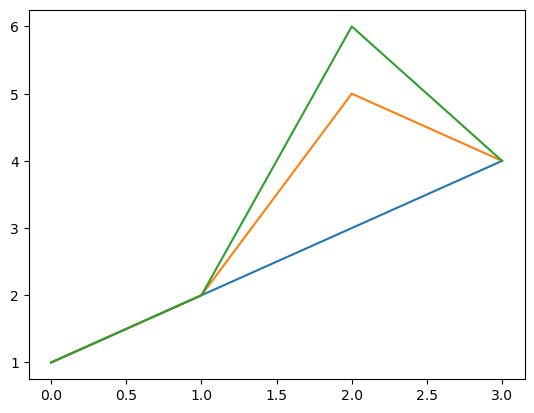

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the points (on the y-axis) 1, 2, 3, 4
plt.plot(np.array([1, 2, 3, 4]))
plt.plot(np.array([1, 2, 5, 4]))
plt.plot(np.array([1, 2, 6, 4]))
plt.show()

### More beautiful plots through labelling and legends
Every plot should contain an axis label and a legend. Especially if several functions are plotted.

This can be done by specifying `label`, `title` as well as `xlabel`, `ylabel`:

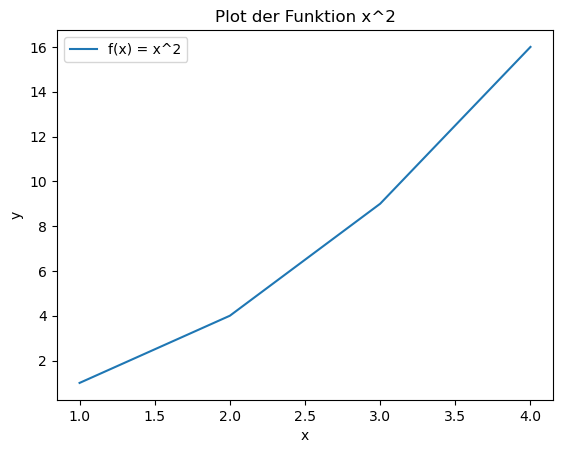

In [96]:
# If we pass two arguments, the first argument refers to the x-coordinate 
# and the second to the corresponding y-values:
plt.plot([1,2,3,4], [1,4,9,16], label="f(x) = x^2")
# With xlabel, ylabel, label and legend we can make the plot a little more meaningful:
plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot der Funktion x^2")
# Show legend:
plt.legend()
plt.show()

### Plotting functions
* In order to plot functions, we must first calculate the data points.
* A vectorised calculation with the help of the numpy library is suitable for this:

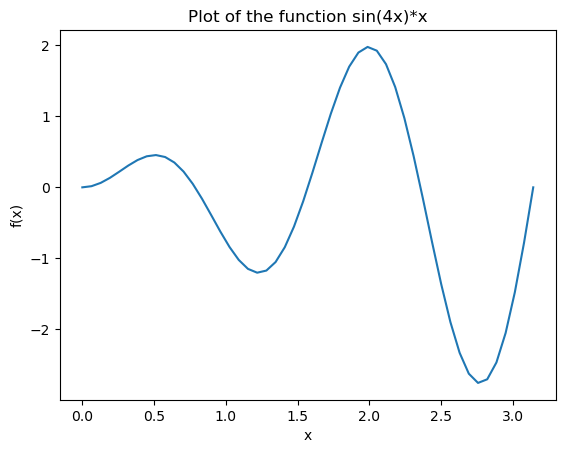

[0.         0.06411414 0.12822827 0.19234241 0.25645654 0.32057068
 0.38468481 0.44879895 0.51291309 0.57702722 0.64114136 0.70525549
 0.76936963 0.83348377 0.8975979  0.96171204 1.02582617 1.08994031
 1.15405444 1.21816858 1.28228272 1.34639685 1.41051099 1.47462512
 1.53873926 1.60285339 1.66696753 1.73108167 1.7951958  1.85930994
 1.92342407 1.98753821 2.05165235 2.11576648 2.17988062 2.24399475
 2.30810889 2.37222302 2.43633716 2.5004513  2.56456543 2.62867957
 2.6927937  2.75690784 2.82102197 2.88513611 2.94925025 3.01336438
 3.07747852 3.14159265]
[ 0.00000000e+00  1.62628444e-02  6.29238635e-02  1.33809257e-01
  2.19306957e-01  3.07320805e-01  3.84487170e-01  4.37546624e-01
  4.54748387e-01  4.27160556e-01  3.49764987e-01  2.22231802e-01
  4.92936814e-02 -1.59327614e-01 -3.89453134e-01 -6.23409050e-01
 -8.41354165e-01 -1.02287456e+00 -1.14872169e+00 -1.20255383e+00
 -1.17253550e+00 -1.05265545e+00 -8.43641475e-01 -5.53378153e-01
 -1.96769609e-01  2.04968343e-01  6.25557912e-01  

In [97]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, np.pi)

# Calculation of the y-values by vectorised operations:
y = np.sin(x*4)*x
plt.plot(x, y)
plt.ylabel('f(x)')
plt.xlabel('x')
plt.title("Plot of the function sin(4x)*x")
plt.show()
print(x)
print(y)

### Data points when plotting
Care should always be taken to use enough points for the plot: Consider the function $f(x) := \sin(1/x)$:

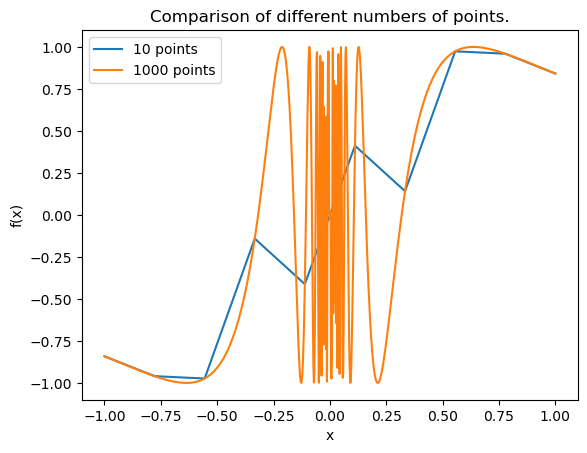

In [98]:
x1 = np.linspace(-1,1,10)
x2 = np.linspace(-1,1,1000)
f = lambda x: np.sin(1/x)

plt.plot(x1, f(x1), label="{:d} points".format(len(x1)))
plt.plot(x2, f(x2), label="{:d} points".format(len(x2)))
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Comparison of different numbers of points.")
plt.show()

### Plot several curves:

 *   By calling the `plot` function several times, several plots can be superimposed.
 *   The colour of the plots is automatically adjusted and the assignment of the legend to the plots is adopted:

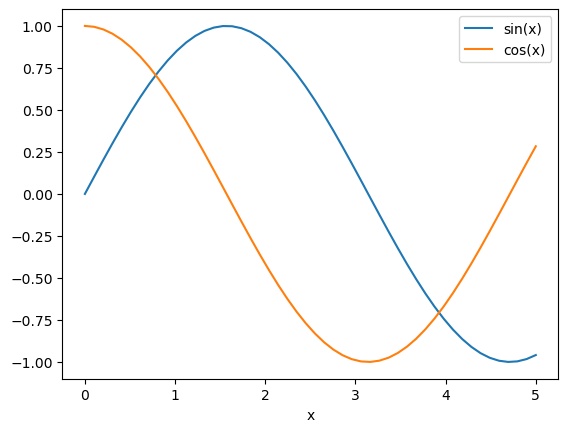

In [99]:
x = np.linspace(0, 5)
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.xlabel("x")
plt.legend()
plt.show()

### Customise the colour and plot style:
Matplotlib works with a formatting string to change the appearance of the individual plots (https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot):

The string is made up of two parts: The line style and the colour:

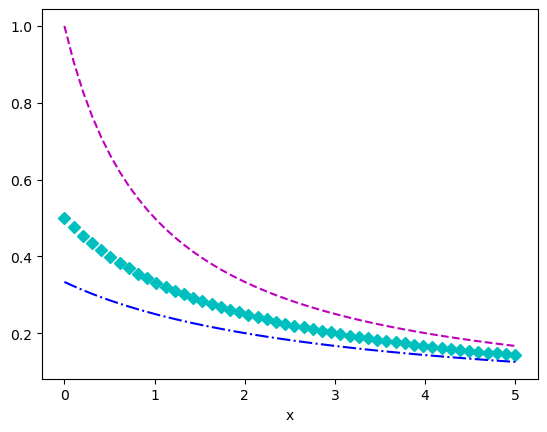

In [100]:
x = np.linspace(0, 5)
# Line style -- and colour m (magenta)
plt.plot(x, 1/(x+1), '--m')
# Line style D (diamond) and colour c (cyan)
plt.plot(x, 1/(x+2), 'Dc')
# Line style -. and colour b (blue)
plt.plot(x, 1/(x+3), '-.b')
plt.xlabel("x")
plt.show()

### Further adaptations of the plot
A plot can be adapted in any way: There are several other keyword arguments that can be used to edit the plot:

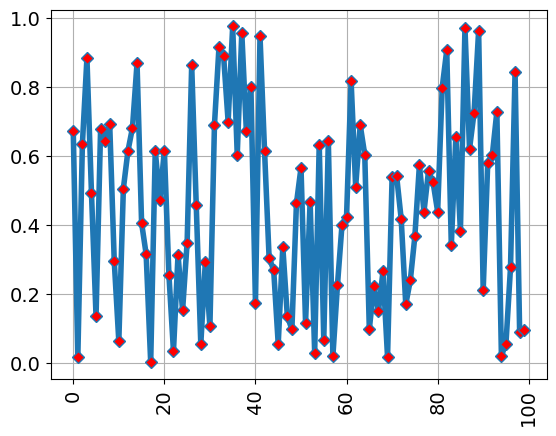

In [101]:
import random 
import numpy as np
import matplotlib.pyplot as plt

y = [random.random() for i in range(100)]
plt.plot(y, linewidth=4, marker="D", markerfacecolor="r")
# Alternative: direct setting of rgb values as color:
#plt.plot(y, linewidth=4, marker="D", markerfacecolor=(1.0, 1.0, 1.0))
plt.grid()
plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)
plt.show()

## Summary
* Python plots with module **matplotlib**
* labelling, legend
* plotting multiple functions
* change color and style
* The plot can be adapted practically at will.